In [ ]:
%pip uninstall -y torch torchvision torchaudio
%pip install librosa
%pip install torch torchvision torchaudio

In [ ]:
%pip install resampy pandas seaborn

In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
from pathlib import Path

In [3]:
import logging
import time

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S"
)

logger = logging.getLogger("audio-analysis")

In [4]:
TWEWY_PATH = Path("J:\\media\\music\\Compilations\\Subarashiki Kono Sekai Original Soundtrack")
NEO_PATH = Path("J:\\media\\music\\Neo The World Ends With You - Original Soundtrack")

songs = list(("TWEWY", mp3) for mp3 in TWEWY_PATH.glob("**/*.mp3") if "._" not in str(mp3)) + list(("NTWEWY", mp3) for mp3 in NEO_PATH.glob("**/*.mp3"))

In [5]:
import torch
import librosa
import numpy as np
from collections import defaultdict
import logging
import time
from pathlib import Path

# Set memory growth (if needed)
torch.backends.cudnn.benchmark = True

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    AutoModel
)


J:\media\.playground-cu118\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "SeyedAli/Musical-genres-Classification-Hubert-V1"

# Load models with appropriate settings
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

# Load models in float32 instead of float16 for better compatibility
clf_model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    dtype=torch.float32
).to(device).eval()

enc_model = AutoModel.from_pretrained(
    model_id,
    output_hidden_states=True,
    dtype=torch.float32
).to(device).eval()

# Enable gradient checkpointing to save memory
if hasattr(clf_model, 'gradient_checkpointing_enable'):
    clf_model.gradient_checkpointing_enable()
if hasattr(enc_model, 'gradient_checkpointing_enable'):
    enc_model.gradient_checkpointing_enable()

In [9]:
CHUNK_SECONDS = 10
CHUNK_SAMPLES = CHUNK_SECONDS * 16_000

def print_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        logger.info(f"GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB")

def chunk_audio(audio, chunk_size):
    for i in range(0, len(audio), chunk_size):
        yield audio[i:i + chunk_size]

def process_chunk(chunk, sr, chunk_idx):
    """Process a single chunk with proper memory management"""
    try:
        # Extract features with appropriate max_length
        inputs = feature_extractor(
            chunk,
            sampling_rate=sr,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=CHUNK_SAMPLES  # Add this line
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        inputs = {k: v.float() for k, v in inputs.items()}
        
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=False):
            # Classifier
            clf_out = clf_model(**inputs)
            pred_id = clf_out.logits.argmax(dim=-1).item()
            label = clf_model.config.id2label[pred_id]
            
            # Encoder
            enc_out = enc_model(**inputs)
            h = enc_out.hidden_states[-1]   # (1, T, D)
            emb = h.mean(dim=1).squeeze()
            
            return label, emb.cpu().numpy()
            
    except Exception as e:
        logger.error(f"Error processing chunk {chunk_idx}: {e}")
        return None, None
    finally:
        # Clear cache
        torch.cuda.empty_cache()

In [10]:
album_data = defaultdict(list)
total_songs = len(songs)
start_time = time.time()

for i, (album, path) in enumerate(songs, 1):
    logger.info(f"[{i}/{total_songs}] Album='{album}' | Loading: {path}")

    try:
        # Load audio with better settings
        audio, sr = librosa.load(
            path, 
            sr=16000,
            mono=True,  # Ensure mono
            res_type='kaiser_fast'  # Faster resampling
        )
    except Exception as e:
        logger.error(f"Failed to load {path}: {e}")
        continue

    chunk_embeddings = []
    chunk_labels = []
    
    # Process in smaller chunks if needed
    CHUNK_SAMPLES = 5 * 16000  # Reduce from 10 to 5 seconds for GTX 1070
    
    for j in range(0, len(audio), CHUNK_SAMPLES):
        chunk = audio[j:j + CHUNK_SAMPLES]
        
        if len(chunk) < 0.5 * CHUNK_SAMPLES:
            continue
        
        # Process chunk
        label, embedding = process_chunk(chunk, sr, j//CHUNK_SAMPLES + 1)
        
        if label is not None and embedding is not None:
            chunk_labels.append(label)
            chunk_embeddings.append(embedding)
        
        # Clear memory periodically
        if j % (5 * CHUNK_SAMPLES) == 0:  # Every 5 chunks
            torch.cuda.empty_cache()

    print_gpu_memory()
    
    if not chunk_embeddings:
        logger.warning(f"No valid chunks for {path}, skipping song.")
        continue
    
    # Aggregate results
    try:
        # Convert to numpy array safely
        embeddings_array = np.stack(chunk_embeddings)
        song_embedding = embeddings_array.mean(axis=0)
        
        # Get most common label
        from collections import Counter
        song_label = Counter(chunk_labels).most_common(1)[0][0]
        
        album_data[album].append({
            "path": str(path),
            "label": song_label,
            "embedding": song_embedding
        })
        
        logger.info(f"Finished {path} | chunks={len(chunk_labels)} | label='{song_label}'")
        
    except Exception as e:
        logger.error(f"Error aggregating results for {path}: {e}")
        continue

elapsed = time.time() - start_time
logger.info(f"Completed processing {total_songs} songs in {elapsed:.1f}s")

16:55:44 | INFO | [1/85] Album='TWEWY' | Loading: J:\media\music\Compilations\Subarashiki Kono Sekai Original Soundtrack\01 It's So Wonderful.mp3
16:55:45 | INFO |   Chunk 1 | samples=80000
C:\Users\G-Tune Robinson\AppData\Local\Temp\ipykernel_2180\195024012.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=False):
16:55:46 | INFO |   Chunk 2 | samples=80000
16:55:47 | INFO |   Chunk 3 | samples=80000
16:55:47 | INFO |   Chunk 4 | samples=80000
16:55:47 | INFO |   Chunk 5 | samples=80000
16:55:47 | INFO |   Chunk 6 | samples=80000
16:55:47 | INFO |   Chunk 7 | samples=80000
16:55:47 | INFO |   Chunk 8 | samples=80000
16:55:47 | INFO |   Chunk 9 | samples=80000
16:55:47 | INFO |   Chunk 10 | samples=80000
16:55:47 | INFO |   Chunk 11 | samples=80000
16:55:47 | INFO |   Chunk 12 | samples=80000
16:55:47 | INFO |   Chunk 13 | samples=80000
16:55:47 | INFO

In [11]:
def album_embeddings(album_songs):
    return np.stack([s["embedding"] for s in album_songs])


In [12]:
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans

In [13]:
def heterogeneity_metrics(X, n_clusters=10):
    """
    X: (N, D) song embeddings for one album
    """
    metrics = {}

    # 4.1 Covariance trace (total variance)
    cov = np.cov(X, rowvar=False)
    metrics["cov_trace"] = np.trace(cov)

    # 4.2 Mean pairwise cosine distance
    metrics["mean_pairwise_cosine"] = pdist(X, metric="cosine").mean()

    # 4.3 Entropy via clustering
    k = min(n_clusters, len(X))
    labels = KMeans(k, n_init=10).fit_predict(X)
    counts = np.bincount(labels)
    p = counts / counts.sum()
    metrics["cluster_entropy"] = -np.sum(p * np.log(p + 1e-9))

    # 4.4 Effective rank
    Xc = X - X.mean(axis=0)
    _, s, _ = np.linalg.svd(Xc, full_matrices=False)
    ps = s / s.sum()
    metrics["effective_rank"] = np.exp(-np.sum(ps * np.log(ps + 1e-9)))

    return metrics


In [50]:
Path(songs_list[0]["path"]).stem

'石元 丈晴 - a tranquil mind'

In [14]:
album_metrics = {}

for album, songs_list in album_data.items():
    X = album_embeddings(songs_list)
    album_metrics[album] = heterogeneity_metrics(X)


In [36]:
album_metrics

{'TWEWY': {'cov_trace': np.float64(50.6237893143102),
  'mean_pairwise_cosine': np.float64(0.5645460485873575),
  'cluster_entropy': np.float64(2.0923261992876747),
  'effective_rank': np.float32(17.87295)},
 'NTWEWY': {'cov_trace': np.float64(38.04783178074804),
  'mean_pairwise_cosine': np.float64(0.45077663130423623),
  'cluster_entropy': np.float64(2.143975173183082),
  'effective_rank': np.float32(19.532518)}}

In [15]:
def bootstrap_metric(X, fn, n=1000):
    vals = []
    for _ in range(n):
        sample = X[np.random.choice(len(X), len(X), replace=True)]
        vals.append(fn(sample))
    return np.mean(vals), np.std(vals)


In [21]:
XA = album_embeddings(album_data["TWEWY"])
XB = album_embeddings(album_data["NTWEWY"])

mean_A, std_A = bootstrap_metric(
    XA,
    lambda x: pdist(x, metric="cosine").mean()
)

mean_B, std_B = bootstrap_metric(
    XB,
    lambda x: pdist(x, metric="cosine").mean()
)


In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_album_embeddings(album, X):
    Z = TSNE(
        n_components=2,
        metric="cosine",
        perplexity=min(30, len(X)-1)
    ).fit_transform(X)

    plt.figure(figsize=(5,5))
    plt.scatter(Z[:,0], Z[:,1], alpha=0.7)
    plt.title(f"Embedding space: {album}")
    plt.show()


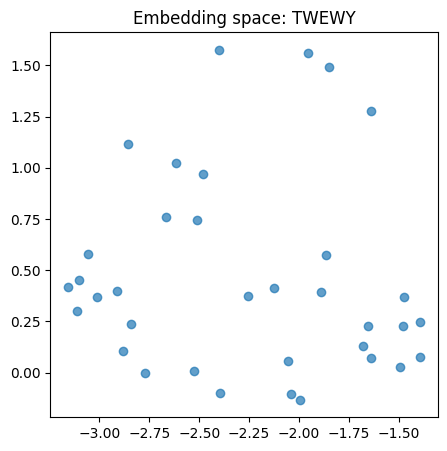

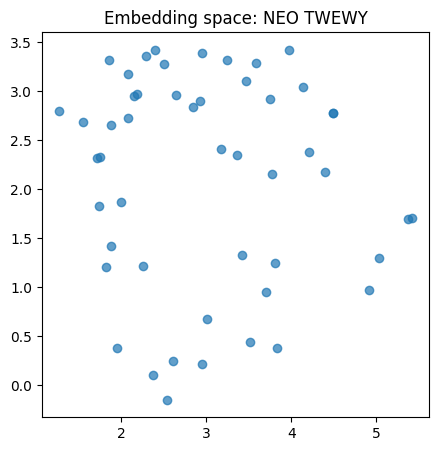

In [24]:
plot_album_embeddings("TWEWY", XA)
plot_album_embeddings("NEO TWEWY", XB)

In [56]:
album_data["NTWEWY"][0].keys()

dict_keys(['path', 'label', 'embedding'])

In [25]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist, squareform
import numpy as np

def album_embeddings(album_songs):
    return np.stack([s["embedding"] for s in album_songs])


def compute_album_metrics(album_name, album_data):
    """Compute comprehensive heterogeneity metrics for an album"""
    X = album_embeddings(album_data[album_name])
    
    metrics = {}
    
    # 1. Mean pairwise cosine distance (higher = more diverse)
    if len(X) > 1:
        cosine_dist = pdist(X, metric='cosine')
        metrics['mean_cosine_distance'] = np.mean(cosine_dist)
        metrics['std_cosine_distance'] = np.std(cosine_dist)
        metrics['max_cosine_distance'] = np.max(cosine_dist)
    else:
        metrics['mean_cosine_distance'] = 0
        metrics['std_cosine_distance'] = 0
        metrics['max_cosine_distance'] = 0
    
    # 2. Variance in embedding space
    metrics['total_variance'] = np.trace(np.cov(X.T))
    metrics['mean_variance'] = np.var(X, axis=0).mean()
    
    # 3. Spread metrics
    centroid = np.mean(X, axis=0)
    distances_to_centroid = np.linalg.norm(X - centroid, axis=1)
    metrics['mean_distance_to_centroid'] = np.mean(distances_to_centroid)
    metrics['std_distance_to_centroid'] = np.std(distances_to_centroid)
    
    # 4. Dimensionality metrics
    # Explained variance ratio
    U, s, Vt = np.linalg.svd(X - X.mean(axis=0))
    explained_variance = (s ** 2) / np.sum(s ** 2)
    metrics['explained_variance_ratio_first_5'] = np.sum(explained_variance[:5])
    metrics['num_dimensions_95%_variance'] = np.where(np.cumsum(explained_variance) > 0.95)[0][0] + 1
    
    # 5. Genre diversity (from classifier labels)
    if album_name in album_data:
        labels = [song['label'] for song in album_data[album_name]]
        unique_labels = set(labels)
        metrics['num_unique_genres'] = len(unique_labels)
        metrics['genre_entropy'] = -sum((labels.count(l)/len(labels)) * np.log(labels.count(l)/len(labels)) 
                                       for l in unique_labels)
    
    return metrics, X

# Compute for both albums
metrics_TWEWY, X_TWEWY = compute_album_metrics("TWEWY", album_data)
metrics_NTWEWY, X_NTWEWY = compute_album_metrics("NTWEWY", album_data)

In [28]:
import pandas as pd

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': list(metrics_TWEWY.keys()),
    'TWEWY': [metrics_TWEWY[m] for m in metrics_TWEWY.keys()],
    'NTWEWY': [metrics_NTWEWY[m] for m in metrics_NTWEWY.keys()],
})

# Add difference column
comparison_df['Difference'] = comparison_df['NTWEWY'] - comparison_df['TWEWY']
comparison_df['% Difference'] = (comparison_df['Difference'] / comparison_df['TWEWY']) * 100

# Sort by absolute difference
comparison_df = comparison_df.reindex(
    comparison_df['Difference'].abs().sort_values(ascending=False).index
)

print("Heterogeneity Metrics Comparison:")
print(comparison_df.to_string())

Heterogeneity Metrics Comparison:
                              Metric      TWEWY     NTWEWY  Difference  % Difference
3                     total_variance  50.623789  38.047832  -12.575958    -24.841992
8        num_dimensions_95%_variance   8.000000   7.000000   -1.000000    -12.500000
9                  num_unique_genres   7.000000   8.000000    1.000000     14.285714
5          mean_distance_to_centroid   6.730350   5.811923   -0.918427    -13.646045
10                     genre_entropy   1.627245   1.384324   -0.242922    -14.928407
0               mean_cosine_distance   0.564546   0.450777   -0.113769    -20.152372
6           std_distance_to_centroid   1.969717   1.873080   -0.096637     -4.906125
1                std_cosine_distance   0.295837   0.267730   -0.028107     -9.500803
2                max_cosine_distance   1.213701   1.191684   -0.022017     -1.814023
4                      mean_variance   0.064033   0.048551   -0.015482    -24.178829
7   explained_variance_ratio_fi

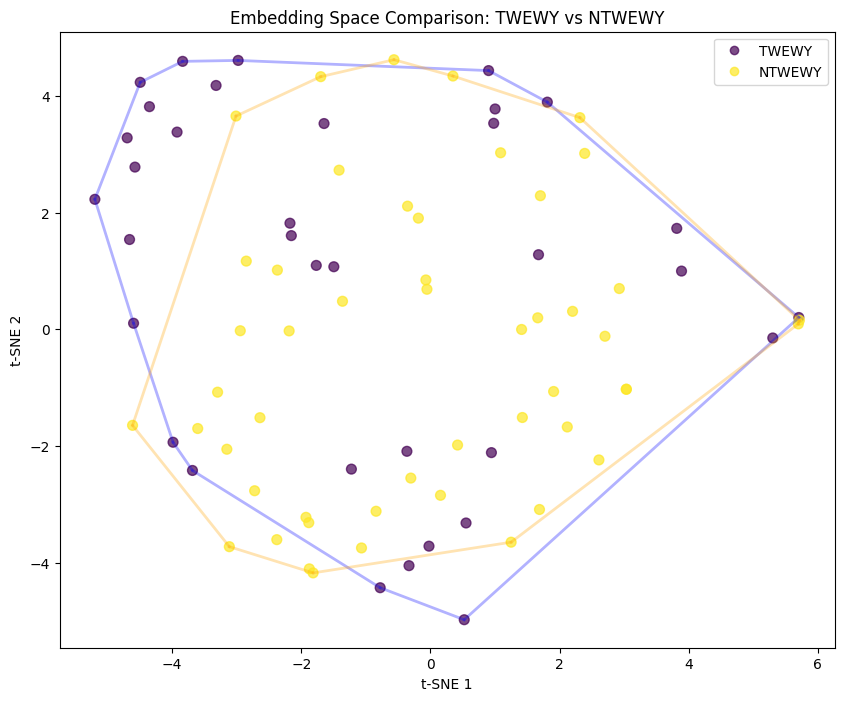

TWEWY convex hull area: 67.41
NTWEWY convex hull area: 59.36


In [32]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

def plot_combined_embeddings(X1, X2, label1="TWEWY", label2="NTWEWY"):
    """Plot both albums' embeddings together for comparison"""
    # Combine embeddings
    X_combined = np.vstack([X1, X2])
    labels = [label1] * len(X1) + [label2] * len(X2)
    
    # t-SNE for visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_combined)-1))
    X_tsne = tsne.fit_transform(X_combined)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                         c=[0 if l == label1 else 1 for l in labels],
                         cmap='viridis', alpha=0.7, s=50)
    
    # Add convex hulls to show spread
    from scipy.spatial import ConvexHull
    colors = ['blue', 'orange']
    for i, (label, color) in enumerate(zip([label1, label2], colors)):
        idx = [j for j, l in enumerate(labels) if l == label]
        if len(idx) >= 3:  # Need at least 3 points for convex hull
            hull = ConvexHull(X_tsne[idx])
            for simplex in hull.simplices:
                plt.plot(X_tsne[idx][simplex, 0], X_tsne[idx][simplex, 1], 
                        color=color, alpha=0.3, linewidth=2)
    
    plt.legend(handles=scatter.legend_elements()[0], labels=[label1, label2])
    plt.title(f"Embedding Space Comparison: {label1} vs {label2}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()
    
    # Print area covered (approximate)
    for label in [label1, label2]:
        idx = [i for i, l in enumerate(labels) if l == label]
        if len(idx) >= 3:
            hull = ConvexHull(X_tsne[idx])
            area = hull.volume if hasattr(hull, 'volume') else hull.area
            print(f"{label} convex hull area: {area:.2f}")

# Plot combined view
plot_combined_embeddings(X_TWEWY, X_NTWEWY)

In [58]:
from pathlib import Path

def album_embeddings_and_names(album_songs):
    X = np.stack([s["embedding"] for s in album_songs])
    names = [Path(s["path"]).stem for s in album_songs]
    return X, names

X_TWEWY, names_TWEWY = album_embeddings_and_names(album_data["TWEWY"])
X_NTWEWY, names_NTWEWY = album_embeddings_and_names(album_data["NTWEWY"])

C:\Users\G-Tune Robinson\AppData\Local\Temp\ipykernel_2180\4255196840.py:63: UserWarning: Glyph 30707 (\N{CJK UNIFIED IDEOGRAPH-77F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\G-Tune Robinson\AppData\Local\Temp\ipykernel_2180\4255196840.py:63: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\G-Tune Robinson\AppData\Local\Temp\ipykernel_2180\4255196840.py:63: UserWarning: Glyph 19976 (\N{CJK UNIFIED IDEOGRAPH-4E08}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\G-Tune Robinson\AppData\Local\Temp\ipykernel_2180\4255196840.py:63: UserWarning: Glyph 26228 (\N{CJK UNIFIED IDEOGRAPH-6674}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
J:\media\.playground-cu118\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30707 (\N{CJK UNIFIED IDEOGRAPH-77F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
J:\media\.playground-cu118\li

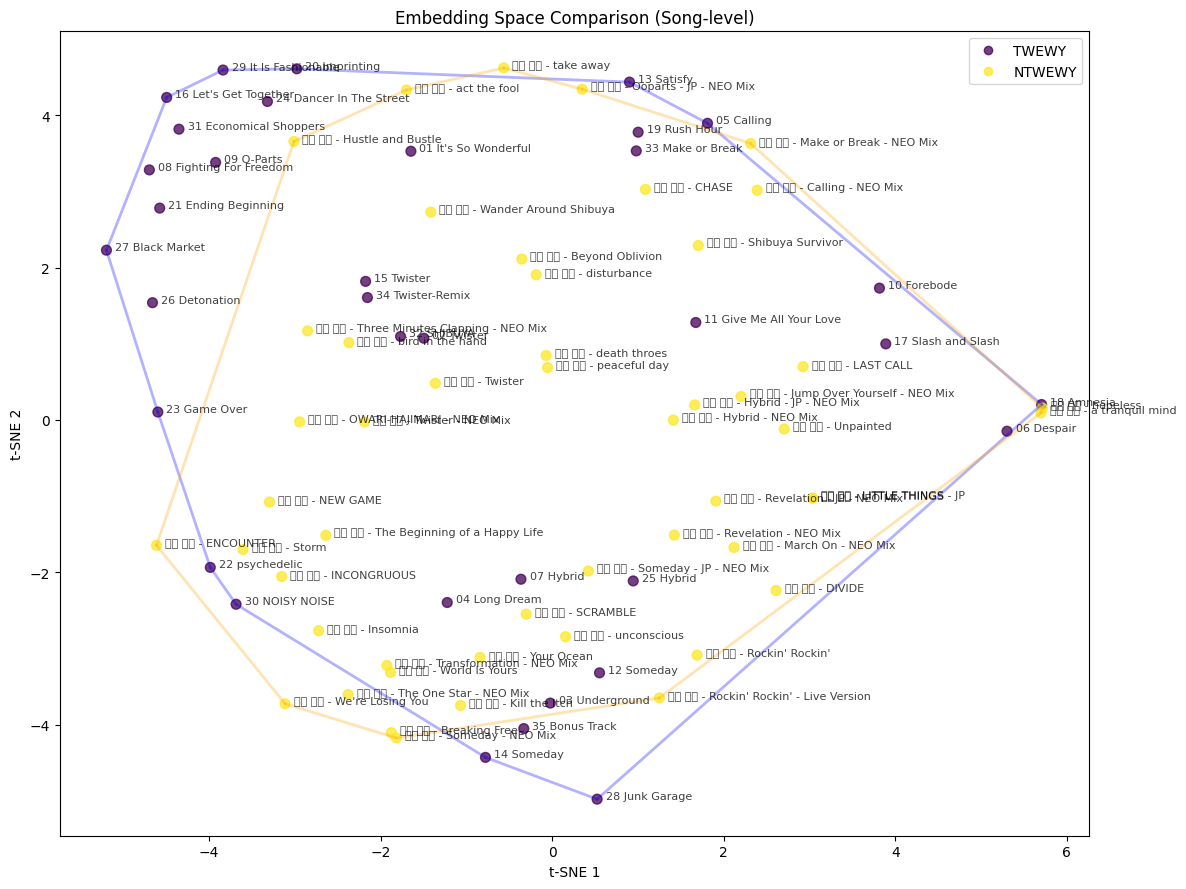

In [62]:
def plot_combined_embeddings(
    X1, names1,
    X2, names2,
    label1="TWEWY", label2="NTWEWY",
    annotate_every=1  # set to 2 or 3 if too crowded
):
    X_combined = np.vstack([X1, X2])
    labels = [label1] * len(X1) + [label2] * len(X2)
    names = names1 + names2

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(30, len(X_combined) - 1)
    )
    X_tsne = tsne.fit_transform(X_combined)

    plt.figure(figsize=(12, 9))

    colors = [0 if l == label1 else 1 for l in labels]
    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=colors,
        cmap="viridis",
        alpha=0.75,
        s=50
    )

    # --- Annotate points ---
    for i, name in enumerate(names):
        if i % annotate_every != 0:
            continue
        plt.text(
            X_tsne[i, 0] + 0.1,
            X_tsne[i, 1],
            name,
            fontsize=8,
            alpha=0.75
        )

    # Convex hulls
    from scipy.spatial import ConvexHull
    hull_colors = ["blue", "orange"]

    for album_label, color in zip([label1, label2], hull_colors):
        idx = [i for i, l in enumerate(labels) if l == album_label]
        if len(idx) >= 3:
            hull = ConvexHull(X_tsne[idx])
            for simplex in hull.simplices:
                plt.plot(
                    X_tsne[idx][simplex, 0],
                    X_tsne[idx][simplex, 1],
                    color=color,
                    alpha=0.3,
                    linewidth=2
                )

    plt.legend(handles=scatter.legend_elements()[0], labels=[label1, label2])
    plt.title("Embedding Space Comparison (Song-level)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

plot_combined_embeddings(
    X_TWEWY, names_TWEWY,
    X_NTWEWY, names_NTWEWY,
    annotate_every=1  # try 2 or 3 if cluttered
)


In [33]:
from scipy import stats

def compare_albums_statistically(X1, X2, label1="TWEWY", label2="NTWEWY"):
    """Run statistical tests to see if differences are significant"""
    
    # Bootstrap confidence intervals for mean cosine distance
    def bootstrap_mean_cosine(X, n_boot=1000):
        means = []
        for _ in range(n_boot):
            idx = np.random.choice(len(X), len(X), replace=True)
            sample = X[idx]
            if len(sample) > 1:
                mean_dist = pdist(sample, metric='cosine').mean()
                means.append(mean_dist)
        return np.mean(means), np.percentile(means, [2.5, 97.5])
    
    mean1, ci1 = bootstrap_mean_cosine(X1)
    mean2, ci2 = bootstrap_mean_cosine(X2)
    
    print(f"\nBootstrap Results (Mean Cosine Distance):")
    print(f"{label1}: {mean1:.4f} (95% CI: {ci1[0]:.4f} - {ci1[1]:.4f})")
    print(f"{label2}: {mean2:.4f} (95% CI: {ci2[0]:.4f} - {ci2[1]:.4f})")
    
    # Check if CIs overlap
    if ci1[1] < ci2[0] or ci2[1] < ci1[0]:
        print("Difference is statistically significant (95% CIs don't overlap)")
    else:
        print("Difference is not statistically significant (95% CIs overlap)")
    
    # Permutation test
    combined = np.vstack([X1, X2])
    labels = np.array([0] * len(X1) + [1] * len(X2))
    
    n_permutations = 1000
    original_diff = np.abs(mean1 - mean2)
    perm_diffs = []
    
    for _ in range(n_permutations):
        np.random.shuffle(labels)
        X1_perm = combined[labels == 0]
        X2_perm = combined[labels == 1]
        
        if len(X1_perm) > 1 and len(X2_perm) > 1:
            mean1_perm = pdist(X1_perm, metric='cosine').mean()
            mean2_perm = pdist(X2_perm, metric='cosine').mean()
            perm_diffs.append(np.abs(mean1_perm - mean2_perm))
    
    p_value = np.mean(perm_diffs >= original_diff)
    print(f"\nPermutation test p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Statistically significant difference (p < 0.05)")
    else:
        print("No statistically significant difference")

# Run statistical comparison
compare_albums_statistically(X_TWEWY, X_NTWEWY)


Bootstrap Results (Mean Cosine Distance):
TWEWY: 0.5489 (95% CI: 0.4658 - 0.6218)
NTWEWY: 0.4411 (95% CI: 0.3636 - 0.5112)
Difference is not statistically significant (95% CIs overlap)

Permutation test p-value: 0.0660
No statistically significant difference


In [34]:
def interpret_results(metrics1, metrics2, label1="TWEWY", label2="NTWEWY"):
    """Provide human-readable interpretation"""
    
    print("\n" + "="*60)
    print("HETEROGENEITY ANALYSIS SUMMARY")
    print("="*60)
    
    # Which album is more diverse?
    key_metrics = ['mean_cosine_distance', 'total_variance', 
                   'mean_distance_to_centroid', 'num_unique_genres']
    
    scores = {label1: 0, label2: 0}
    
    for metric in key_metrics:
        if metric in metrics1 and metric in metrics2:
            if metrics1[metric] > metrics2[metric]:
                scores[label1] += 1
                print(f"• {metric.replace('_', ' ').title()}: {label1} is more diverse")
            elif metrics2[metric] > metrics1[metric]:
                scores[label2] += 1
                print(f"• {metric.replace('_', ' ').title()}: {label2} is more diverse")
            else:
                print(f"• {metric.replace('_', ' ').title()}: Equal diversity")
    
    print("\n" + "-"*60)
    print(f"OVERALL: ", end="")
    if scores[label1] > scores[label2]:
        print(f"{label1} appears more heterogeneous ({scores[label1]}/{len(key_metrics)} metrics)")
    elif scores[label2] > scores[label1]:
        print(f"{label2} appears more heterogeneous ({scores[label2]}/{len(key_metrics)} metrics)")
    else:
        print("Albums appear similarly heterogeneous")
    
    # Genre analysis
    if 'num_unique_genres' in metrics1:
        print(f"\nGenre Analysis:")
        print(f"  {label1}: {metrics1['num_unique_genres']} unique genres")
        print(f"  {label2}: {metrics2['num_unique_genres']} unique genres")

# Get interpretation
interpret_results(metrics_TWEWY, metrics_NTWEWY)


HETEROGENEITY ANALYSIS SUMMARY
• Mean Cosine Distance: TWEWY is more diverse
• Total Variance: TWEWY is more diverse
• Mean Distance To Centroid: TWEWY is more diverse
• Num Unique Genres: NTWEWY is more diverse

------------------------------------------------------------
OVERALL: TWEWY appears more heterogeneous (3/4 metrics)

Genre Analysis:
  TWEWY: 7 unique genres
  NTWEWY: 8 unique genres


In [45]:
# 在你现有的处理循环之前添加这些变量
all_song_data = []
song_names = []
embeddings_list = []
labels_list = []
albums_list = []

# 修改你的处理循环（大概是第10个代码单元格之后的部分）
# 找到这个循环：
for idx, (album, mp3_path) in enumerate(songs, 1):
    logger.info(f"[{idx}/{len(songs)}] Album='{album}' | Loading: {mp3_path}")
    
    try:
        audio, sr = librosa.load(mp3_path, sr=16_000)
        logger.info(f"  Loaded audio: {len(audio)} samples")
        
        chunk_labels = []
        chunk_embeddings = []
        
        # 处理每个chunk
        for chunk_idx, chunk in enumerate(chunk_audio(audio, CHUNK_SAMPLES), 1):
            logger.info(f"  Chunk {chunk_idx} | samples={len(chunk)}")
            
            label, emb = process_chunk(chunk, sr, chunk_idx)
            
            if label is not None and emb is not None:
                chunk_labels.append(label)
                chunk_embeddings.append(emb)
        
        # 确定整个歌曲的主要标签（使用最常见的标签）
        if chunk_labels:
            from collections import Counter
            most_common_label = Counter(chunk_labels).most_common(1)[0][0]
            
            # 计算平均embedding
            avg_embedding = np.mean(chunk_embeddings, axis=0)
            
            # 收集数据
            song_name = mp3_path.stem  # 获取文件名（不带扩展名）
            
            all_song_data.append({
                'album': album,
                'song_name': song_name,
                'full_path': str(mp3_path),
                'genre': most_common_label,
                'embedding': avg_embedding,
                'num_chunks': len(chunk_labels)
            })
            
            song_names.append(song_name)
            embeddings_list.append(avg_embedding)
            labels_list.append(most_common_label)
            albums_list.append(album)
            
            logger.info(f"Finished {mp3_path} | chunks={len(chunk_labels)} | label='{most_common_label}'")
        else:
            logger.warning(f"No valid chunks for {mp3_path}")
            
    except Exception as e:
        logger.error(f"Error processing {mp3_path}: {e}")
    
    # 定期清理GPU内存
    if idx % 10 == 0:
        torch.cuda.empty_cache()
        print_gpu_memory()

# 处理完成后，将数据转换为合适的格式
embeddings_array = np.array(embeddings_list)

logger.info(f"Processing complete! Processed {len(all_song_data)} songs.")
logger.info(f"Genre distribution: {Counter(labels_list)}")

# 保存数据以便后续使用
import pickle

data_to_save = {
    'song_data': all_song_data,
    'song_names': song_names,
    'embeddings': embeddings_array,
    'labels': labels_list,
    'albums': albums_list
}

with open('song_classification_results.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

logger.info("Data saved to 'song_classification_results.pkl'")

17:39:25 | INFO | [1/85] Album='TWEWY' | Loading: J:\media\music\Compilations\Subarashiki Kono Sekai Original Soundtrack\01 It's So Wonderful.mp3
17:39:25 | INFO |   Loaded audio: 1584427 samples
17:39:25 | INFO |   Chunk 1 | samples=80000
C:\Users\G-Tune Robinson\AppData\Local\Temp\ipykernel_2180\195024012.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=False):
17:39:25 | INFO |   Chunk 2 | samples=80000
17:39:25 | INFO |   Chunk 3 | samples=80000
17:39:25 | INFO |   Chunk 4 | samples=80000
17:39:25 | INFO |   Chunk 5 | samples=80000
17:39:25 | INFO |   Chunk 6 | samples=80000
17:39:25 | INFO |   Chunk 7 | samples=80000
17:39:26 | INFO |   Chunk 8 | samples=80000
17:39:26 | INFO |   Chunk 9 | samples=80000
17:39:26 | INFO |   Chunk 10 | samples=80000
17:39:26 | INFO |   Chunk 11 | samples=80000
17:39:26 | INFO |   Chunk 12 | samples=80000
17:39:26 |

KeyboardInterrupt: 